# DATA-445 In-Class Assignment 2

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 2 assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area.

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [10]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

house_price = pd.read_csv('Real_Estate.csv')
house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 2. (3 points) Drop the `No` column.

In [3]:
house_price=house_price.drop(columns=['No'], axis=1)

## 3. (4 points) Create a scatter plot of `house_age` and `house_price_of_unit_area`. Describe the plot.

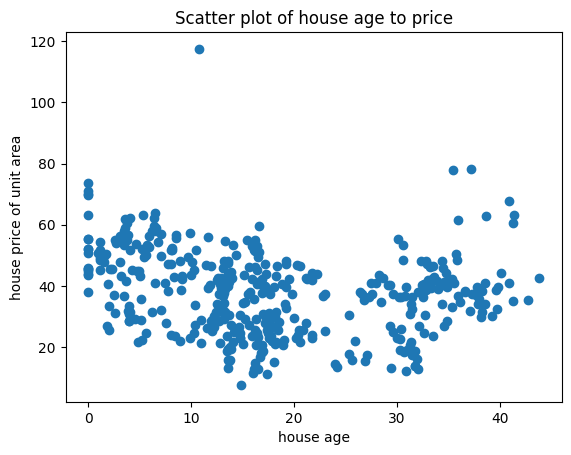

In [8]:
plt.scatter(house_price["house_age"], house_price['house_price_of_unit_area'])
plt.title("Scatter plot of house age to price")
plt.xlabel("house age")
plt.ylabel("house price of unit area")
plt.show()

# There are two groups of houses (newer(less than or equal to 25 years old) and older(greater than or equal to 25 years old)). The house price
# associated with unit area of each of those groups behave different (most likely from location).

## 4. (4 points) Create a scatter plot of `distance_to_the_nearest_MRT_station` and `house_price_of_unit_area`. Describe the plot.

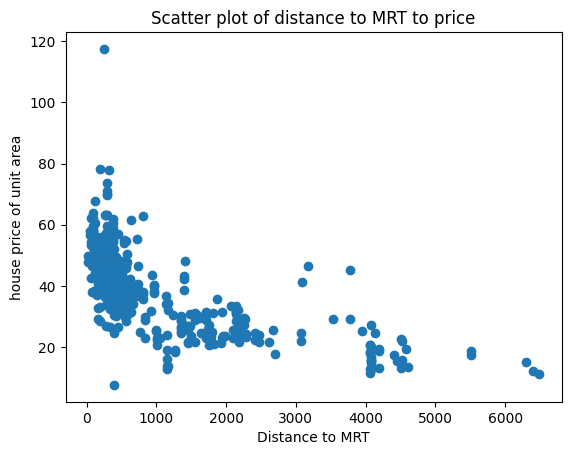

In [9]:
plt.scatter(house_price["distance_to_the_nearest_MRT_station"], house_price['house_price_of_unit_area'])
plt.title("Scatter plot of distance to MRT to price")
plt.xlabel("Distance to MRT")
plt.ylabel("house price of unit area")
plt.show()

# Closer to the MRT station on average the more expensive the house.

## 5. (5 points) Build a linear regression model

Input variables: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude`.

Target variable: `house_price_of_unit_area`.

In [11]:
x = house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude']]
y = house_price['house_price_of_unit_area']

lin_reg = LinearRegression()
lin_reg.fit(x,y)

print('Intercept: ', lin_reg.intercept_.round(3))
print('Coefficient: ', dict(zip(x.columns, lin_reg.coef_.round(4))))

Intercept:  -4945.595
Coefficient:  {'house_age': -0.2689, 'distance_to_the_nearest_MRT_station': -0.0043, 'number_of_convenience_stores': 1.163, 'latitude': 237.7672, 'longitude': -7.8055}


## 6. (3 points) Using the model from part 5, predict the house price of unit area

For a house with: `house_age = 5`, `distance_to_the_nearest_MRT_station = 500`, `number_of_convenience_stores = 3`, `latitude = 24.98`, and `longitude = 121.49`.

In [13]:
house1 = pd.DataFrame({
    'house_age':[5],
    'distance_to_the_nearest_MRT_station':[500],
    'number_of_convenience_stores': [3],
    'latitude': [24.98],
    'longitude': [121.49]
})

predict_price = lin_reg.predict(house1).round(3)
print("Predicted house in the area: ", predict_price[0])

Predicted house in the area:  45.56
